# Clusterizando trayectorias en Nezahualcóyotl

In [1]:
import stmeasures
import utils

Y ahora se obtiene el dataset con el que se trabajará

In [2]:
dataset = stmeasures.read_file('../assets/ECATEPEC.json')
trajectories = utils.get_only_trajectories(dataset, 5000)

Y se define el modelo con el que se buscan obtener 10 clusters

In [3]:
from sklearn.cluster import AgglomerativeClustering
model = AgglomerativeClustering(n_clusters=50, metric='precomputed', linkage='average')

## Euclideano

In [4]:
labels_eu1 = model.fit_predict(utils.compute_distance_matrix(trajectories, utils.euclidean_distance1))

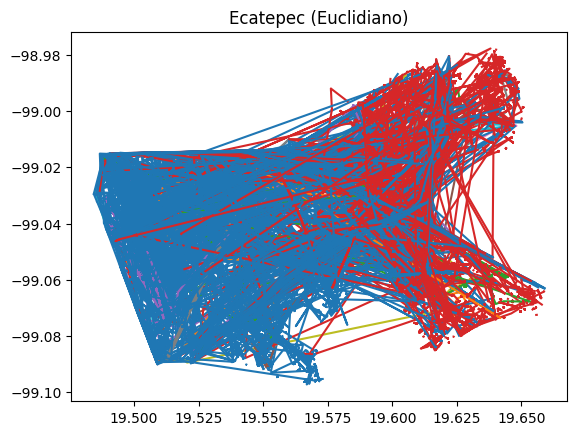

In [5]:
utils.plot_clusters(trajectories, labels_eu1, "Ecatepec (Euclidiano)")

### `Shapely`

In [6]:
labels_eu2 = model.fit_predict(utils.compute_distance_matrix(trajectories, utils.euclidean_distance2))

/home/edev/devel/similarity-measures/venv/lib/python3.12/site-packages/shapely/measurement.py:72: RuntimeWarning: invalid value encountered in distance
  return lib.distance(a, b, **kwargs)


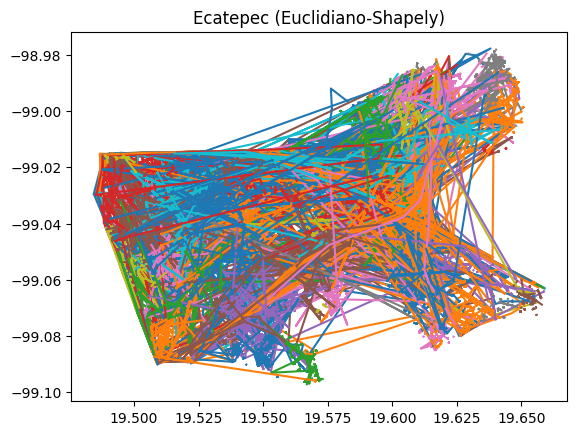

In [7]:
utils.plot_clusters(trajectories, labels_eu2, "Ecatepec (Euclidiano-Shapely)")

## Hausdorff

In [8]:
labels_ha = model.fit_predict(utils.compute_distance_matrix(trajectories, utils.hausdorff_distance))

/home/edev/devel/similarity-measures/venv/lib/python3.12/site-packages/shapely/measurement.py:218: RuntimeWarning: invalid value encountered in hausdorff_distance
  return lib.hausdorff_distance(a, b, **kwargs)


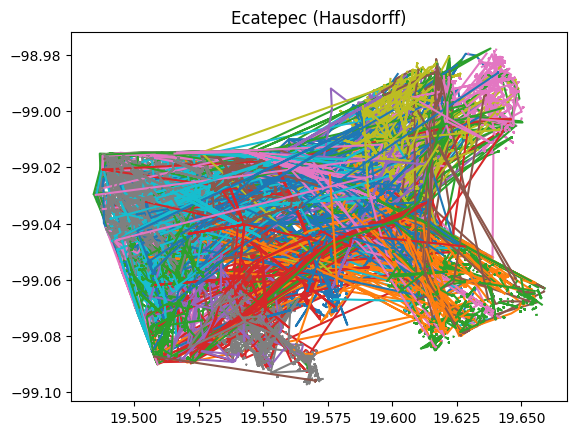

In [9]:
utils.plot_clusters(trajectories, labels_ha, "Ecatepec (Hausdorff)")

## Frechet

In [10]:
labels_fr = model.fit_predict(utils.compute_distance_matrix(trajectories, utils.frechet_distance))

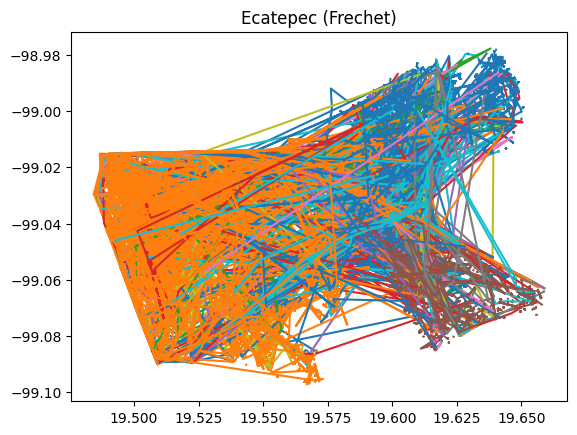

In [11]:
utils.plot_clusters(trajectories, labels_fr, "Ecatepec (Frechet)")

## Spatial Assembling

In [12]:
labels_sp = model.fit_predict(utils.compute_distance_matrix(trajectories, stmeasures.spatialassem_distance))

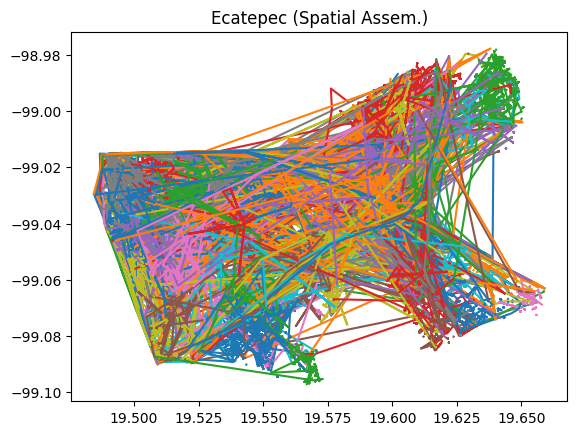

In [13]:
utils.plot_clusters(trajectories, labels_sp, "Ecatepec (Spatial Assem.)")

# Guardando las etiquetas de clusterizado

In [14]:
import csv

def save_labels(labels, filename):
    with open(filename, mode="w", newline="") as file:
        writer = csv.writer(file)
        writer.writerow(labels)

In [15]:
save_labels(labels_eu1, "labels_50eu1.csv")

In [16]:
save_labels(labels_eu2, "labels_50eu2.csv")

In [17]:
save_labels(labels_fr, "labels_50fr.csv")

In [18]:
save_labels(labels_ha, "labels_50ha.csv")

In [19]:
save_labels(labels_sp, "labels_50sp.csv")

# Guardando las trayectorias

In [20]:
import json

def save_trajectories(trajectories, filename=""):
    jsondata = [
        [[x, y] for x, y in trajectory] for trajectory in trajectories
    ]

    with open(filename, "w") as file:
        json.dump(jsondata, file, indent=4)

In [21]:
save_trajectories(trajectories, "trajectories50.json")